# Figure 5
## Time series correlation plots from FANTOM5 datasets
### Author: Martin Loza
### Date: 25/12/30

Let's plot the combined results from different FANTOM5 datasets

In [10]:
# Change R language to English
Sys.setenv(LANGUAGE = "en") 

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
    library(ggvenn)
    library(ComplexHeatmap)
    library(circlize)
})

# Local variables 
seed = 777
date = "251230"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
gray = "gray50"

text_size = 18
width = 18.6
height = 5
dot_size = 4
line_size = 1.5
dpi = 300

fantom_coexpression_results = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/09_FANTOM5_time_course_analyses/Results/Gene_pairs_FANTOM_expression/"
fantom_selected_pairs <- "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/10_Figure_5/Results/selected_significant_gene_pairs_FANTOM_4_plotting_251230.tsv"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/10_Figure_5/Results/"
plots_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/10_Figure_5/Results/Plots/"
tables_out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Supplementary/"
# Local Functions

# Function to create time series plot for a gene pair with scaled expression
create_timeseries_plot <- function(data_row, dataset_name, 
                                    scale_data = TRUE, 
                                    alpha = 0.8,
                                    x_text_size = text_size - 2,
                                    title_text_size = text_size) {
    # Extract time point columns for lncRNA and TF
    lncrna_cols <- grep("^lncRNA_tpm_", colnames(data_row), value = TRUE)
    tf_cols <- grep("^TF_tpm_", colnames(data_row), value = TRUE)
    
    # Extract expression values
    lncrna_expr <- as.numeric(data_row[lncrna_cols])
    tf_expr <- as.numeric(data_row[tf_cols])
    
    # Extract time points from column names
    time_points <- gsub("lncRNA_tpm_.*_", "", lncrna_cols)
    
    # Get gene names for legend
    gene_name <- data_row$gene_name_pair_id.x
    if (is.na(gene_name)) {
        gene_name <- data_row$gene_pair_id
    }
    gene_names <- strsplit(gene_name, "_")[[1]]
    lncrna_name <- gene_names[1]
    tf_name <- gene_names[2]
    
    # Scale expression values using z-score normalization if requested
    if (scale_data) {
        lncrna_scaled <- scale(lncrna_expr)[,1]
        tf_scaled <- scale(tf_expr)[,1]
        expr_values <- c(lncrna_scaled, tf_scaled)
        y_label <- "Scaled TSS expression"
    } else {
        expr_values <- c(lncrna_expr, tf_expr)
        y_label <- " TSS expression (TPM)"
    }
    
    # Create long format data for plotting
    plot_data <- data.frame(
        TimePoint = rep(time_points, 2),
        Expression = expr_values,
        Gene = rep(c(lncrna_name, tf_name), each = length(time_points)),
        Order = rep(seq_along(time_points), 2)
    )

    # Set the Gene as a factor to control legend order
    plot_data$Gene <- factor(plot_data$Gene, levels = c(lncrna_name, tf_name))
    
    pearson_r <- round(data_row$pearson_correlation, 3)
    
    # Create time series plot with both genes
    p <- ggplot(plot_data, aes(x = Order, y = Expression, color = Gene, group = Gene)) +
        geom_line(linewidth = line_size, alpha = alpha) +
        geom_point(size = dot_size, alpha = alpha) +
        scale_color_manual(values = c(purple, green)) +
        scale_x_continuous(breaks = 1:length(time_points), 
                          labels = time_points) +
        labs(
            title = gene_name,
            subtitle = paste0("Pearson r = ", pearson_r),
            x = "Time Point",
            y = y_label,
            color = "Gene"
        ) +
        theme_classic() +
        theme(
            text = element_text(size = text_size),
            plot.title = element_text(face = "bold", size = title_text_size + 2),
            plot.subtitle = element_text(size = title_text_size),
            axis.title = element_text(size = title_text_size),
            axis.text = element_text(size = x_text_size),
            axis.text.x = element_text(angle = 45, hjust = 1),
            # legend.position = c(0.85, 0.85),
            legend.title = element_text(face = "bold"),
            legend.background = element_rect(fill = "white", color = "black", linewidth = 0.5),
            legend.box.background = element_rect(color = "black", linewidth = 0.5)
        )
    
    return(p)
}


### Load and setup the data

In [11]:
datasets <- c("Lymphatic", "Aortic", "MCF7", "Monocyte-derived", "Saos-2")

data_list <- lapply(datasets, function(dataset) {
    # Load data
    data_file <- paste0(fantom_coexpression_results, dataset, "_251230.tsv")
    data <- read.table(data_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    data$Dataset <- dataset
    return(data)
})

head(data_list[[1]])

,gene_pair_id,gene_name_pair_id,lncRNA_Family,avg_correlation,overall_rank,is_DT,is_AS,ncrna_tss,pcg_tss,chromosome,⋯,TF_tpm_Lymphatic_02hr00min,TF_tpm_Lymphatic_02hr30min,TF_tpm_Lymphatic_03hr00min,TF_tpm_Lymphatic_03hr30min,TF_tpm_Lymphatic_04hr,TF_tpm_Lymphatic_05hr,TF_tpm_Lymphatic_06hr,TF_tpm_Lymphatic_07hr,TF_tpm_Lymphatic_08hr,Dataset
,<chr>,<chr>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<int>,<int>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ENSG00000227640_ENSG00000125285,SOX21-AS1_SOX21,HMG,0.9682961,1,FALSE,TRUE,94712716,94712545,13,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
2,ENSG00000263146_ENSG00000256463,LINC01896_SALL3,zf-C2H2,0.9499586,2,FALSE,FALSE,78979074,78979818,18,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
3,ENSG00000277268_ENSG00000273706,LHX1-DT_LHX1,Homeobox,0.9465009,3,TRUE,FALSE,36936670,36936784,17,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
4,ENSG00000236502_ENSG00000138083,SIX3-AS1_SIX3,Homeobox,0.9460684,4,FALSE,TRUE,44941582,44941702,2,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
5,ENSG00000255399_ENSG00000089225,TBX5-AS1_TBX5,T-box,0.9433313,5,FALSE,TRUE,114408426,114408442,12,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,Lymphatic
6,ENSG00000240990_ENSG00000005073,HOXA11-AS_HOXA11,Homeobox,0.9392763,6,FALSE,TRUE,27185235,27185232,7,⋯,0.2524562,0.1809412,0.3409931,0.3568161,0.1989531,0.254626,0.3412625,0.1461522,0.53154,Lymphatic


Let's merge the coexpression results across datasets

In [12]:
# Load selected significant gene pairs from previous analyses
selected_fantom <- read.table(fantom_selected_pairs, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
head(selected_fantom)

,gene_pair_id,lncRNA_gene_id,TF_gene_id,n_samples,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr,⋯,ncrna_tss,pcg_tss,Family,abs_strand_distance,gene_name_pair_id,avg_correlation,overall_rank,is_DT,is_AS,num_datasets_significant
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<int>
1,ENSG00000240990_ENSG00000005073,ENSG00000240990_27185235,ENSG00000005073_27185232,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,27185235,27185232,Homeobox,3,HOXA11-AS_HOXA11,0.9392763,6,FALSE,TRUE,2
2,ENSG00000230844_ENSG00000251192,ENSG00000230844_46545438,ENSG00000251192_46545441,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,46545438,46545441,zf-C2H2,3,ZNF674-AS1_ZNF674,0.8993300,18,FALSE,TRUE,2
3,ENSG00000225733_ENSG00000177463,ENSG00000225733_14947538,ENSG00000177463_14947544,16,1,5.574538e-111,8.215109e-111,1,0,0,⋯,14947538,14947544,RXR-like,6,FGD5-AS1_NR2C2,0.8207711,74,FALSE,TRUE,5
4,ENSG00000283122_ENSG00000118495,ENSG00000283122_144008262,ENSG00000118495_144008261,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,144008262,144008261,zf-C2H2,1,HYMAI_PLAGL1,0.8193061,76,FALSE,FALSE,5
5,ENSG00000269834_ENSG00000167555,ENSG00000269834_52397807,ENSG00000167555_52397849,16,1,5.574538e-111,8.215109e-111,1,0,0,⋯,52397807,52397849,zf-C2H2,42,ZNF528-AS1_ZNF528,0.8058113,91,FALSE,TRUE,5
6,ENSG00000267886_ENSG00000183850,ENSG00000267886_23075211,ENSG00000183850_23075210,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,23075211,23075210,zf-C2H2,1,unnamed_ZNF730,0.8014170,97,FALSE,FALSE,2


In [13]:
# Filter gene pairs with correlation < 1.0 (not perfect correlation)
# # and merge with expression data
# non_perfect_pairs <- selected_fantom %>%
#     filter(pearson_correlation < 1.0) %>%
#     arrange(desc(avg_correlation))
non_perfect_pairs <- selected_fantom

cat("Number of gene pairs with non-perfect correlation:", nrow(non_perfect_pairs), "\n")
cat("Correlation range:", min(non_perfect_pairs$pearson_correlation), "-", max(non_perfect_pairs$pearson_correlation), "\n")
head(non_perfect_pairs)

Number of gene pairs with non-perfect correlation: 116 
Correlation range: 0.4902893 - 1 


,gene_pair_id,lncRNA_gene_id,TF_gene_id,n_samples,pearson_correlation,pearson_pvalue,pearson_fdr,spearman_correlation,spearman_pvalue,spearman_fdr,⋯,ncrna_tss,pcg_tss,Family,abs_strand_distance,gene_name_pair_id,avg_correlation,overall_rank,is_DT,is_AS,num_datasets_significant
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<lgl>,<lgl>,<int>
1,ENSG00000240990_ENSG00000005073,ENSG00000240990_27185235,ENSG00000005073_27185232,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,27185235,27185232,Homeobox,3,HOXA11-AS_HOXA11,0.9392763,6,FALSE,TRUE,2
2,ENSG00000230844_ENSG00000251192,ENSG00000230844_46545438,ENSG00000251192_46545441,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,46545438,46545441,zf-C2H2,3,ZNF674-AS1_ZNF674,0.8993300,18,FALSE,TRUE,2
3,ENSG00000225733_ENSG00000177463,ENSG00000225733_14947538,ENSG00000177463_14947544,16,1,5.574538e-111,8.215109e-111,1,0,0,⋯,14947538,14947544,RXR-like,6,FGD5-AS1_NR2C2,0.8207711,74,FALSE,TRUE,5
4,ENSG00000283122_ENSG00000118495,ENSG00000283122_144008262,ENSG00000118495_144008261,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,144008262,144008261,zf-C2H2,1,HYMAI_PLAGL1,0.8193061,76,FALSE,FALSE,5
5,ENSG00000269834_ENSG00000167555,ENSG00000269834_52397807,ENSG00000167555_52397849,16,1,5.574538e-111,8.215109e-111,1,0,0,⋯,52397807,52397849,zf-C2H2,42,ZNF528-AS1_ZNF528,0.8058113,91,FALSE,TRUE,5
6,ENSG00000267886_ENSG00000183850,ENSG00000267886_23075211,ENSG00000183850_23075210,16,1,0.000000e+00,0.000000e+00,1,0,0,⋯,23075211,23075210,zf-C2H2,1,unnamed_ZNF730,0.8014170,97,FALSE,FALSE,2


In [14]:
# Find gene pairs with expression data in each dataset
# We'll check which datasets have expression data for our non-perfect pairs

gene_pairs_with_data <- list()

for (i in seq_along(data_list)) {
    dataset_name <- unique(data_list[[i]]$Dataset)[1]
    
    # Find which non-perfect pairs are in this dataset
    pairs_in_dataset <- non_perfect_pairs %>%
        filter(Dataset == dataset_name) %>%
        inner_join(data_list[[i]], by = c("gene_pair_id", "Dataset"))
    
    if (nrow(pairs_in_dataset) > 0) {
        gene_pairs_with_data[[dataset_name]] <- pairs_in_dataset
        cat(dataset_name, ":", nrow(pairs_in_dataset), "gene pairs with expression data\n")
    }
}

# Show summary of available gene pairs
cat("\nTotal datasets with data:", length(gene_pairs_with_data), "\n")

# Display gene pairs available for plotting
for (dataset_name in names(gene_pairs_with_data)) {
    cat("\n", dataset_name, ":\n", sep = "")
    summary_df <- gene_pairs_with_data[[dataset_name]] %>%
        select(gene_pair_id, gene_name_pair_id.x, pearson_correlation, lncRNA_Family) %>%
        distinct() %>%
        arrange(desc(pearson_correlation))
    print(summary_df)
}

Lymphatic : 21 gene pairs with expression data
Aortic : 16 gene pairs with expression data
MCF7 : 30 gene pairs with expression data
Monocyte-derived : 21 gene pairs with expression data
Saos-2 : 28 gene pairs with expression data

Total datasets with data: 5 

Lymphatic:
                      gene_pair_id gene_name_pair_id.x pearson_correlation
1  ENSG00000240990_ENSG00000005073    HOXA11-AS_HOXA11                   1
2  ENSG00000230844_ENSG00000251192   ZNF674-AS1_ZNF674                   1
3  ENSG00000225733_ENSG00000177463      FGD5-AS1_NR2C2                   1
4  ENSG00000283122_ENSG00000118495        HYMAI_PLAGL1                   1
5  ENSG00000269834_ENSG00000167555   ZNF528-AS1_ZNF528                   1
6  ENSG00000267886_ENSG00000183850      unnamed_ZNF730                   1
7  ENSG00000273329_ENSG00000106459        unnamed_NRF1                   1
8  ENSG00000232104_ENSG00000080298        RFX3-DT_RFX3                   1
9  ENSG00000268362_ENSG00000213096      unnamed_ZNF2

### Supplementary Figures

Let's combine selected plots into a multi-panel figure. One Figure for each dataset

In [15]:
# Create plots for each dataset
plots_dataset <- list()
for (dataset_name in names(gene_pairs_with_data)) {
    dataset_pairs <- gene_pairs_with_data[[dataset_name]]

    for (i in 1:nrow(dataset_pairs)) {
        data_row <- dataset_pairs[i, ]
        plot <- create_timeseries_plot(data_row, dataset_name,
                    scale_data = FALSE,
                    alpha = 0.6, 
                    x_text_size = text_size - 5,
                    title_text_size = text_size - 2)
        plot_name <- paste0(data_row$gene_pair_id, "_", dataset_name)
        plots_dataset[[plot_name]] <- plot
    }
}

In [16]:
# Create merged plots for each dataset
for (dataset in datasets){
    sel_plots <- plots_dataset[grep(dataset, names(plots_dataset))]
    n_plots <- length(sel_plots)

    # Merge plots for selected dataset
    for (i in seq_along(sel_plots)) {
        # for (i in 1:5) {
        plot_name <- names(sel_plots)[i]
        plot <- sel_plots[[i]]
        if (i == 1) {
            merged_plot <- plot
        } else {
            merged_plot <- merged_plot + plot
        }
    }
    # change the size of the displayed figure
    options(repr.plot.width=width, repr.plot.height=(height -1)* ceiling(n_plots / 5))
    # options(repr.plot.width=30, repr.plot.height=5)
    merged_plot <- (merged_plot & 
                        scale_color_manual(values = c(purple, green), labels = c("lncRNA", "TF"))  & 
                        theme(legend.position = "bottom") )  +
                            plot_layout(ncol = 5, guides = "collect") + 
                            plot_annotation(
                                title = paste0("Time series TSS expression plots - ", dataset),
                                theme = theme(
                                    plot.title = element_text(size = text_size + 4, face = "bold", hjust = 0.5)
                                )
                            )

    # Save merged plot to file
    output_file <- paste0(plots_out_dir, "Supplementary_time_series_", dataset, "_", date, ".pdf")
    ggsave(output_file, merged_plot, width = width, height = (height -1)* ceiling(n_plots / 5), dpi = dpi)
}

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is

### Plots of selected gene pairs

We will select for main visualizations those gene pairs with correlation less than 1

In [17]:
selected_pairs <- lapply(gene_pairs_with_data, function(x) {
    sel_x <- x %>% filter(pearson_correlation != 1.0)
    return(sel_x)
})
# Remove empty dfs
selected_pairs <- selected_pairs[sapply(selected_pairs, nrow) > 0]
# selected_pairs

In [25]:
# Create plots for each selected pairs. We will scale the expression values
plots <- list()
for (dataset_name in names(selected_pairs)) {
    dataset_pairs <- selected_pairs[[dataset_name]]

    for (i in 1:nrow(dataset_pairs)) {
        data_row <- dataset_pairs[i, ]
        # Set the gene pair label
        gene_pair_label <- str_replace(data_row$gene_name_pair_id.x,pattern = "_", replacement = "/")
        # print(gene_pair_label)
        pearson_r <- round(data_row$pearson_correlation, 3)
        plot <- create_timeseries_plot(data_row, dataset_name,
                    scale_data = TRUE,
                    alpha = 0.6, 
                    x_text_size = text_size - 5,
                    title_text_size = text_size - 2) +
                    labs(title = paste0(dataset_name, "\n", gene_pair_label),
                         subtitle = paste0("Pearson r = ", pearson_r))
        plot_name <- paste0(data_row$gene_pair_id, "_", dataset_name)
        plots[[paste0(gene_pair_label, "_", dataset_name)]] <- plot
    }
}

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is

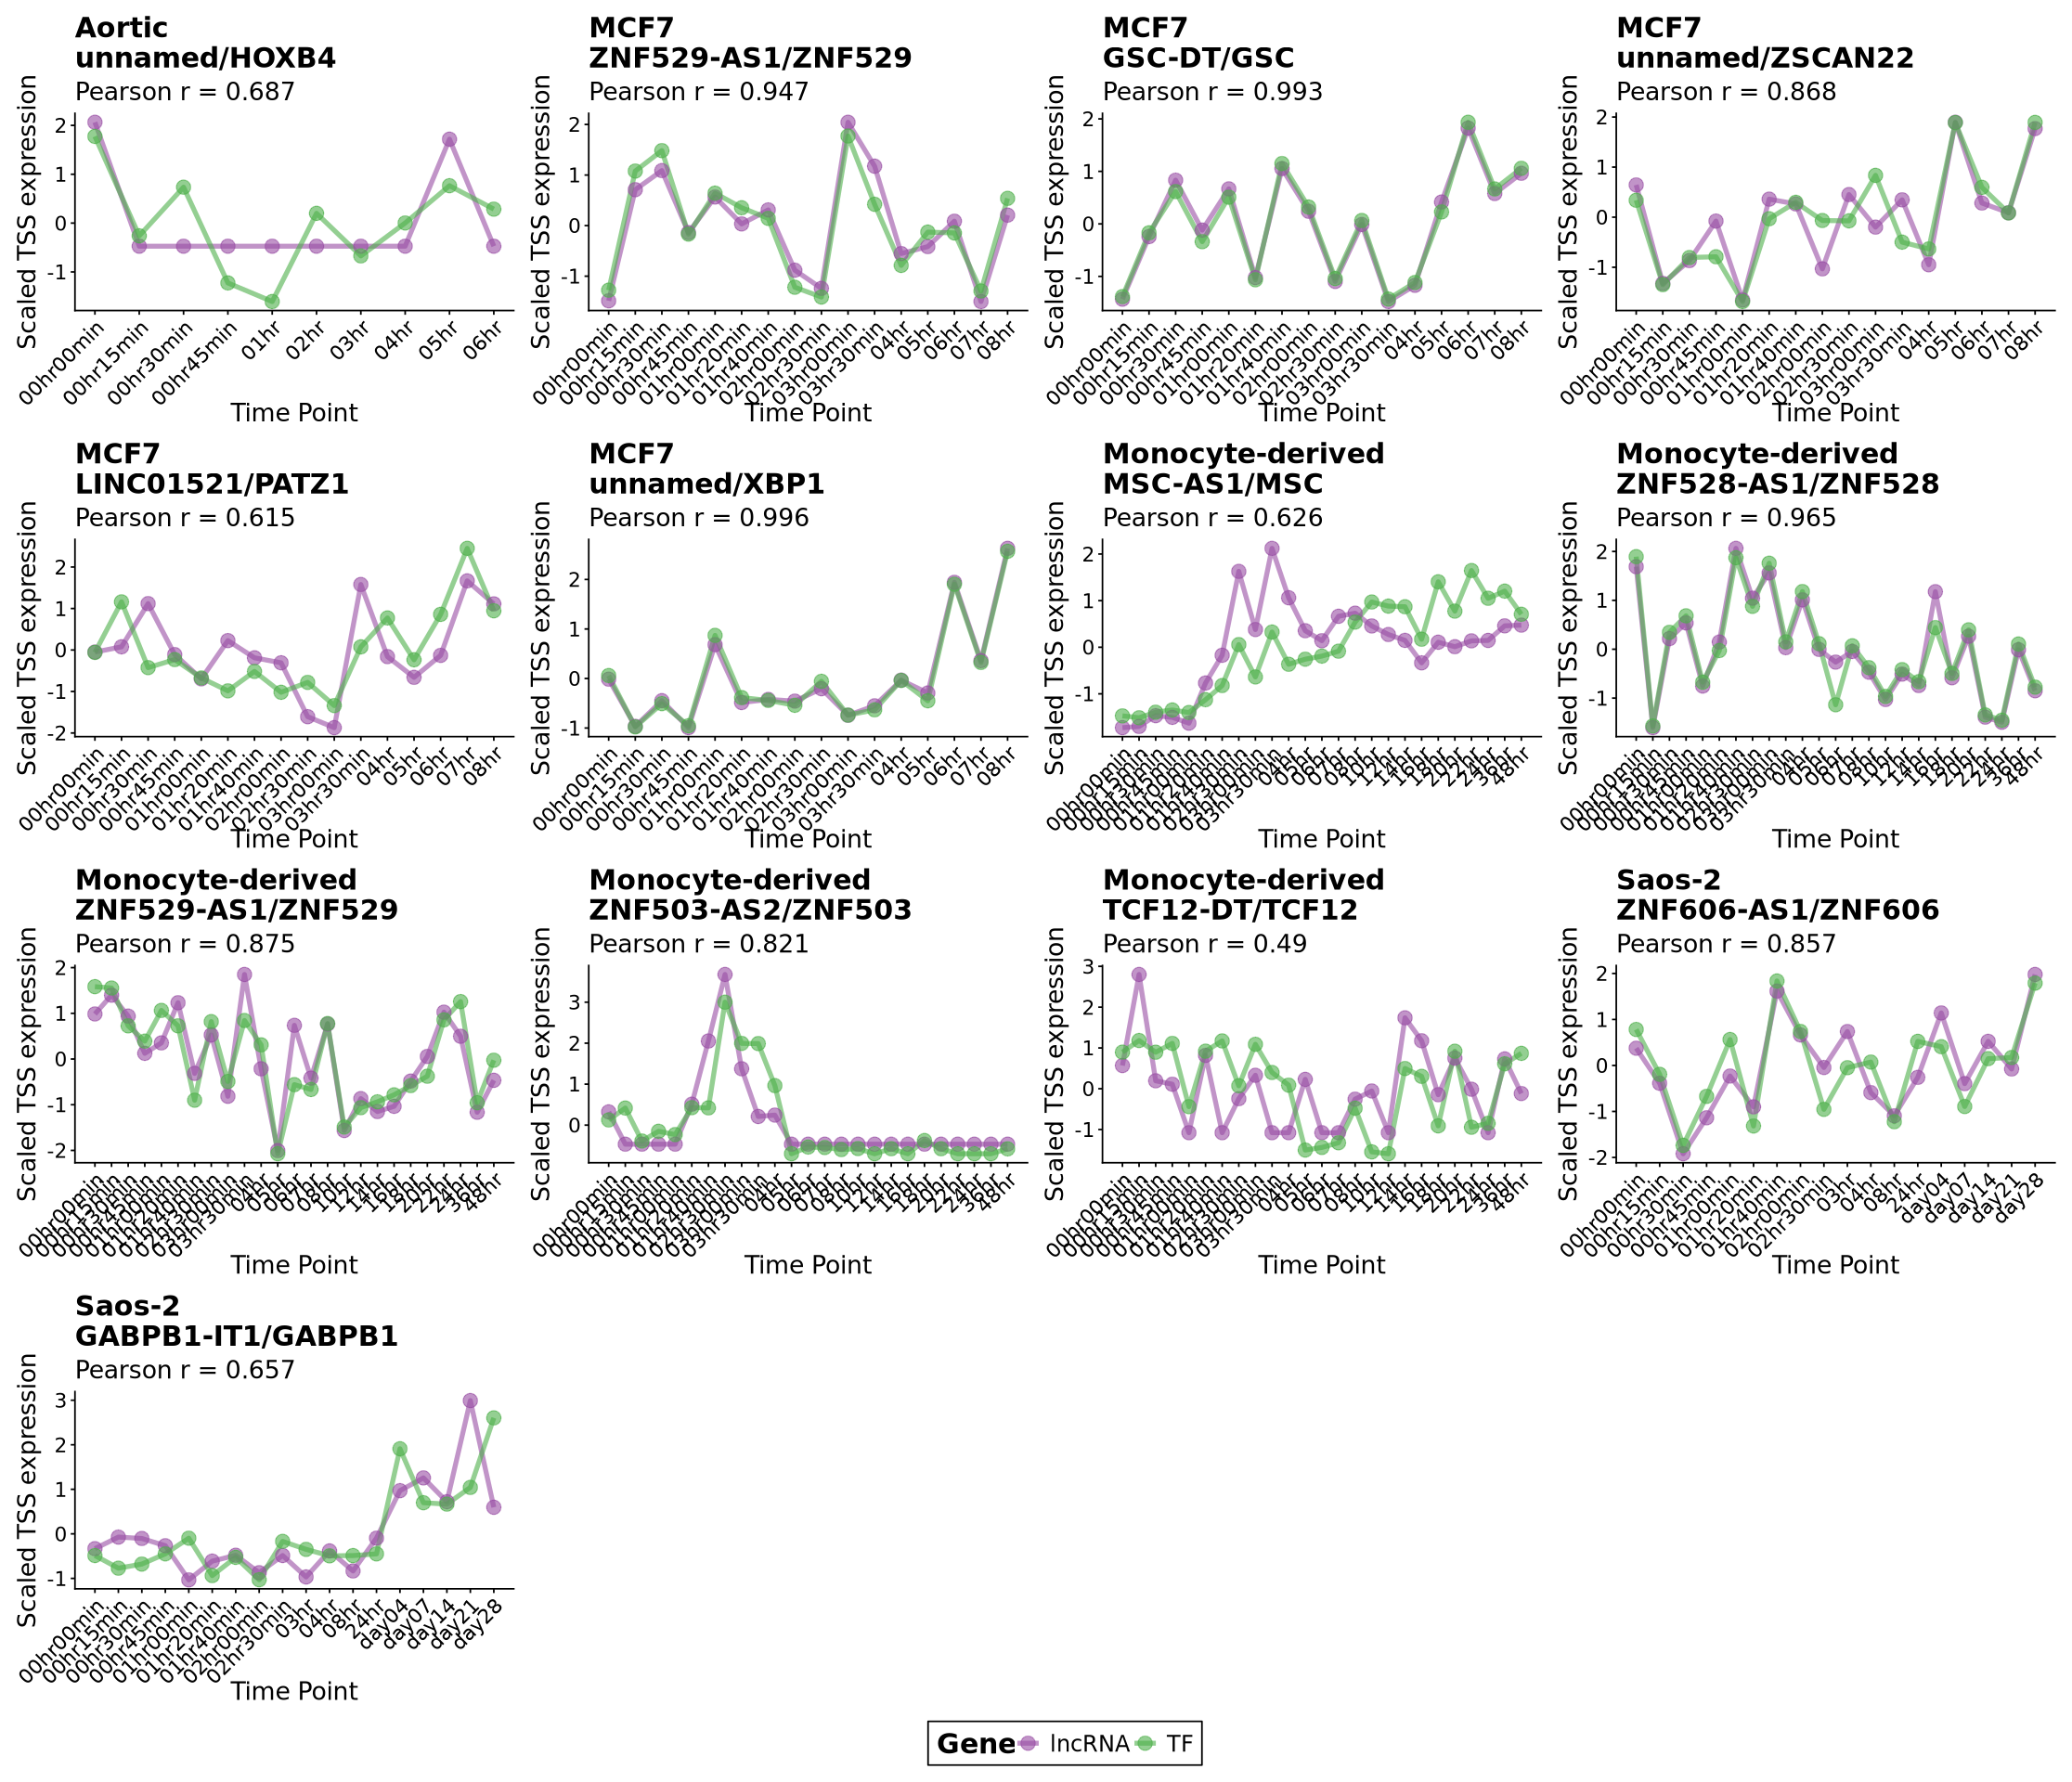

In [26]:
n_plots <- length(plots)
# Merge the plots into a single object
merged_plot <- (wrap_plots(plots, ncol = 4) & 
    scale_color_manual(values = c(purple, green), labels = c("lncRNA", "TF"))  & 
    theme(legend.position = "bottom")) +
    plot_layout(guides = "collect") 
# change the size of the displayed figure
options(repr.plot.width=width, repr.plot.height=(height -1)* ceiling(n_plots / 4))
merged_plot

# Save merged plot to file
output_file <- paste0(plots_out_dir, "Supplementary_time_series_selected_", date, ".pdf")
ggsave(output_file, merged_plot, width = width, height = (height)* ceiling(n_plots / 4), dpi = dpi)

LEt's plot a couple of example for the main Figure

In [27]:
names(plots)

[1] "unnamed/HOXB4_Aortic"               "ZNF529-AS1/ZNF529_MCF7"            
 [3] "GSC-DT/GSC_MCF7"                    "unnamed/ZSCAN22_MCF7"              
 [5] "LINC01521/PATZ1_MCF7"               "unnamed/XBP1_MCF7"                 
 [7] "MSC-AS1/MSC_Monocyte-derived"       "ZNF528-AS1/ZNF528_Monocyte-derived"
 [9] "ZNF529-AS1/ZNF529_Monocyte-derived" "ZNF503-AS2/ZNF503_Monocyte-derived"
[11] "TCF12-DT/TCF12_Monocyte-derived"    "ZNF606-AS1/ZNF606_Saos-2"          
[13] "GABPB1-IT1/GABPB1_Saos-2"

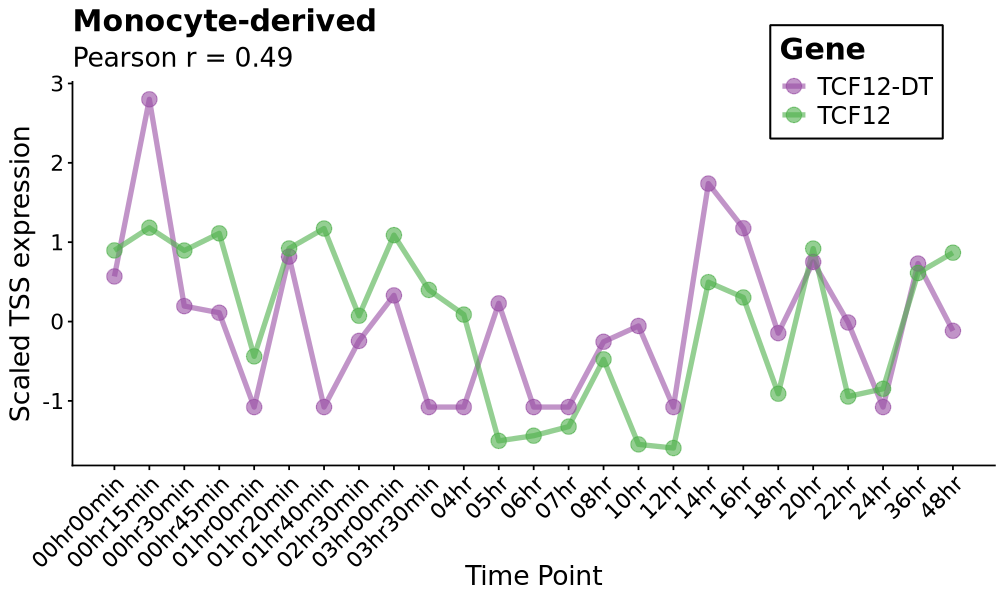

In [28]:
worst_correlation <- c("TCF12-DT_TCF12")
dataset <- "Monocyte-derived"

# Create the plot for the selected worst correlation pair
sel_pair_data <- selected_pairs[[dataset]] %>%
    filter(gene_name_pair_id.x == worst_correlation)

# Set the gene pair label
gene_pair_label <- str_replace(sel_pair_data$gene_name_pair_id.x,pattern = "_", replacement = "/")
# print(gene_pair_label)
pearson_r <- round(sel_pair_data$pearson_correlation, 3)
p <- create_timeseries_plot(sel_pair_data, dataset,
            scale_data = TRUE,
            alpha = 0.6, 
            x_text_size = text_size - 5,
            title_text_size = text_size - 2) +
            labs(title = paste0(dataset),
                    subtitle = paste0("Pearson r = ", pearson_r)) +
            theme(legend.position = c(0.85, 1))

 
options(repr.plot.width=width*.45, repr.plot.height=height)
p

# Save merged plot to file
output_file <- paste0(plots_out_dir, "Selected_worst_correlation_", date, ".pdf")
ggsave(output_file, p, width = width * 0.45, height = height, dpi = dpi)

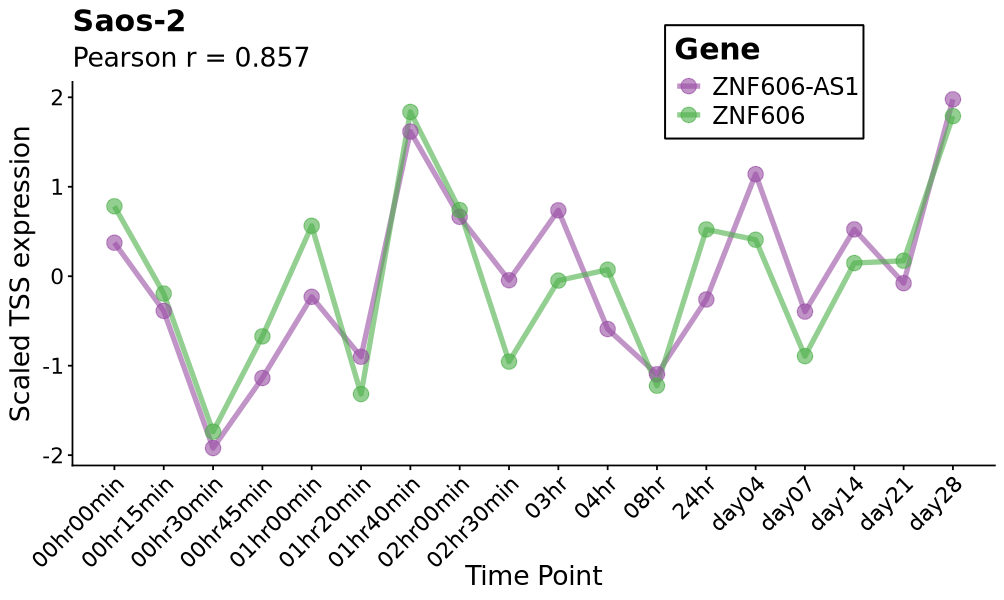

In [29]:
selected_pair <- c('ZNF606-AS1_ZNF606')
dataset <- "Saos-2"

# Create the plot for the selected worst correlation pair
sel_pair_data <- selected_pairs[[dataset]] %>%
    filter(gene_name_pair_id.x == selected_pair)

# Set the gene pair label
gene_pair_label <- str_replace(sel_pair_data$gene_name_pair_id.x,pattern = "_", replacement = "/")
# print(gene_pair_label)
pearson_r <- round(sel_pair_data$pearson_correlation, 3)
p <- create_timeseries_plot(sel_pair_data, dataset,
            scale_data = TRUE,
            alpha = 0.6, 
            x_text_size = text_size - 5,
            title_text_size = text_size - 2) +
            labs(title = paste0(dataset),
                    subtitle = paste0("Pearson r = ", pearson_r)) +
            theme(legend.position = c(0.75, 1))

 
options(repr.plot.width=width*.45, repr.plot.height=height)
p

# Save merged plot to file
output_file <- paste0(plots_out_dir, "Selected_good_correlation_", date, ".pdf")
ggsave(output_file, p, width = width * 0.45, height = height, dpi = dpi)

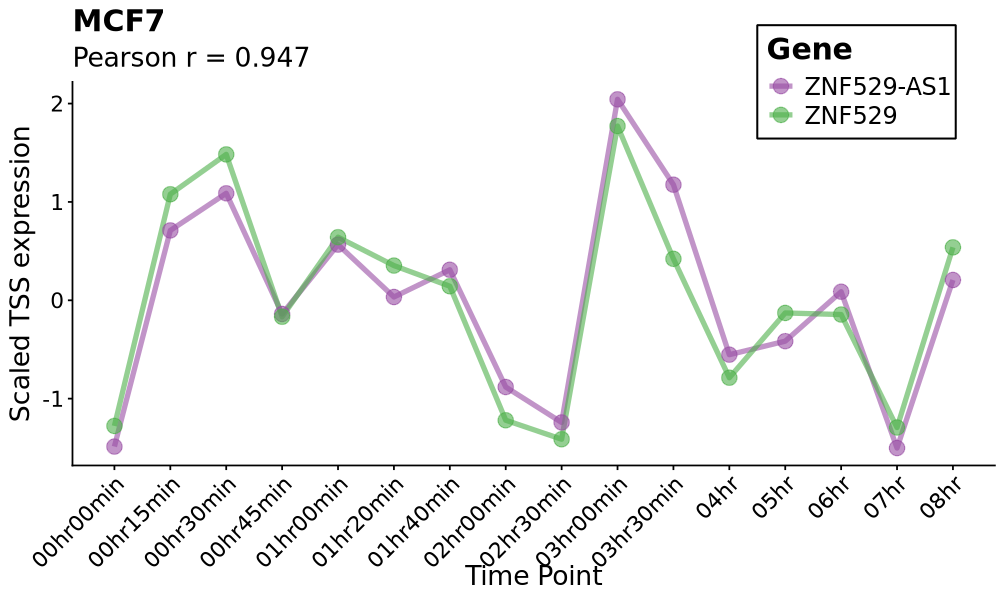

In [30]:
selected_pair <- c('ZNF529-AS1_ZNF529')
dataset <- "MCF7"

# Create the plot for the selected worst correlation pair
sel_pair_data <- selected_pairs[[dataset]] %>%
    filter(gene_name_pair_id.x == selected_pair)

# Set the gene pair label
gene_pair_label <- str_replace(sel_pair_data$gene_name_pair_id.x,pattern = "_", replacement = "/")
# print(gene_pair_label)
pearson_r <- round(sel_pair_data$pearson_correlation, 3)
p1 <- create_timeseries_plot(sel_pair_data, dataset,
            scale_data = TRUE,
            alpha = 0.6, 
            x_text_size = text_size - 5,
            title_text_size = text_size - 2) +
            labs(title = paste0(dataset),
                    subtitle = paste0("Pearson r = ", pearson_r)) +
            theme(legend.position = c(0.85, 1))

 
options(repr.plot.width=width*.45, repr.plot.height=height)
p1

# Save merged plot to file
output_file <- paste0(plots_out_dir, "Selected_529_MCF7_correlation_", date, ".pdf")
ggsave(output_file, p1, width = width * 0.45, height = height, dpi = dpi)

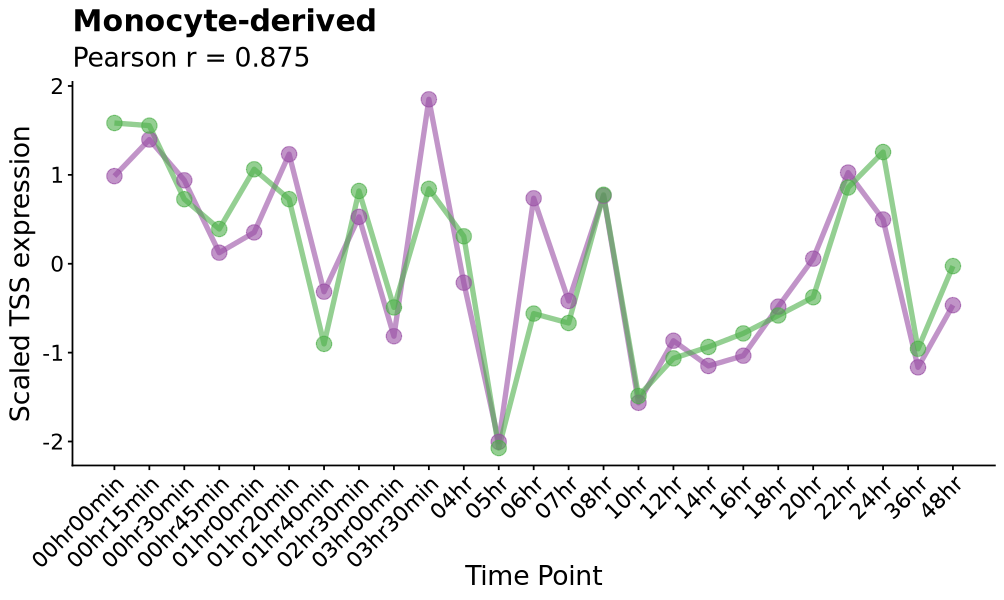

In [31]:
selected_pair <- c('ZNF529-AS1_ZNF529')
dataset <- "Monocyte-derived"

# Create the plot for the selected worst correlation pair
sel_pair_data <- selected_pairs[[dataset]] %>%
    filter(gene_name_pair_id.x == selected_pair)

# Set the gene pair label
gene_pair_label <- str_replace(sel_pair_data$gene_name_pair_id.x,pattern = "_", replacement = "/")
# print(gene_pair_label)
pearson_r <- round(sel_pair_data$pearson_correlation, 3)
p2 <- create_timeseries_plot(sel_pair_data, dataset,
            scale_data = TRUE,
            alpha = 0.6, 
            x_text_size = text_size - 5,
            title_text_size = text_size - 2) +
            labs(title = paste0(dataset),
                    subtitle = paste0("Pearson r = ", pearson_r)) +
            theme(legend.position = "none")

 
options(repr.plot.width=width*.45, repr.plot.height=height)
p2

# Save merged plot to file
output_file <- paste0(plots_out_dir, "Selected_529_Monocyte-derived_correlation_", date, ".pdf")
ggsave(output_file, p2, width = width * 0.45, height = height, dpi = dpi)

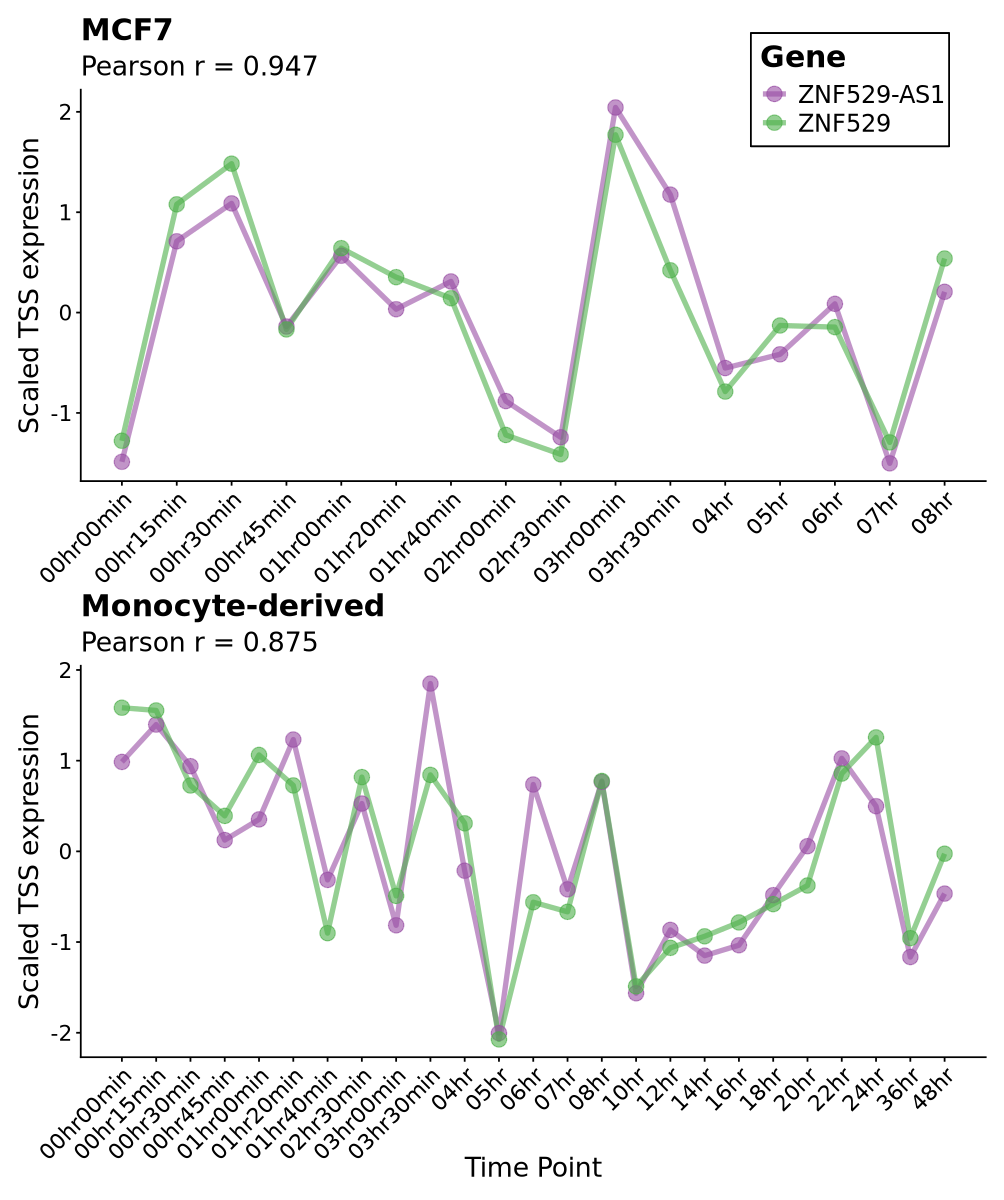

In [32]:
options(repr.plot.width=width*.45, repr.plot.height=height*2)
merged_plot <- ((p1 + theme(axis.title.x = element_blank())) / p2) + 
    plot_layout(heights = c(1.0,1)) 

merged_plot

# Save merged plot to file
output_file <- paste0(plots_out_dir, "Selected_529_combined_", date, ".pdf")
ggsave(output_file, merged_plot, width = width * 0.45, height = height*2, dpi = dpi)